In [1]:
import torch
from torch.utils.data import Dataset
import numpy as np

class RoadDataset(Dataset):

    def __init__(
        self,
        recordings,
        window_size=128,
        stride=32,
        has_labels=False,
    ):
        self.recordings = recordings
        self.window_size = window_size
        self.has_labels = has_labels

        self.indices = []

        for rec_idx, rec in enumerate(recordings):

            T = rec.shape[0]

            for start in range(0, T - window_size + 1, stride):
                self.indices.append((rec_idx, start))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):

        rec_idx, start = self.indices[idx]

        window = self.recordings[rec_idx][
            start:start+self.window_size
        ]

        if self.has_labels:

            x = window[:, :-1].astype(np.float32)
            y = window[:, -1]
            action = x[-1, 0]

            # Window is anomalous if any timestep is anomalous
            # label = int(np.any(y))
            label = int(y.mean() > 0.5)
            # label = y[-1]

            return (
                torch.from_numpy(x),
                torch.tensor(label, dtype=torch.long), torch.tensor(action)
            )

        else:

            x = window.astype(np.float32)

            return torch.from_numpy(x)

### Training Loader

In [2]:
from RoADDataset import Dataset
from torch.utils.data import DataLoader

road = Dataset(normalize=True)

train_dataset = RoadDataset(
    road.sets["training"],
    window_size=128,
    stride=32,
    has_labels=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

### LSTM Model Defination

In [3]:
import torch
import torch.nn as nn


class LSTMAutoEncoder(nn.Module):

    def __init__(
        self,
        input_dim=86,
        hidden_dim=128,
        latent_dim=64,
        num_layers=2,
        dropout=0.2,
    ):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        self.dropout = dropout

        # --------------------------------------------------
        # Encoder
        # --------------------------------------------------

        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        # Compress encoder states
        self.hidden_fc = nn.Linear(hidden_dim, latent_dim)
        self.cell_fc = nn.Linear(hidden_dim, latent_dim)

        # Recover decoder states
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_dim)
        self.latent_to_cell = nn.Linear(latent_dim, hidden_dim)

        # --------------------------------------------------
        # Decoder
        # --------------------------------------------------

        self.decoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )

        self.output_layer = nn.Linear(
            hidden_dim,
            input_dim
        )

        # Learnable SOS token
        self.start_token = nn.Parameter(
            torch.zeros(1, 1, input_dim)
        )

    # --------------------------------------------------

    def encode(self, x):

        _, (hidden, cell) = self.encoder(x)

        hidden_last = hidden[-1]
        cell_last = cell[-1]

        z_hidden = self.hidden_fc(hidden_last)
        z_cell = self.cell_fc(cell_last)

        return z_hidden, z_cell

    # --------------------------------------------------

    def decode(
        self,
        z_hidden,
        z_cell,
        seq_len,
    ):

        batch_size = z_hidden.size(0)

        hidden = self.latent_to_hidden(z_hidden)
        cell = self.latent_to_cell(z_cell)

        hidden = (
            hidden
            .unsqueeze(0)
            .repeat(self.num_layers, 1, 1)
        )

        cell = (
            cell
            .unsqueeze(0)
            .repeat(self.num_layers, 1, 1)
        )

        decoder_input = self.start_token.repeat(
            batch_size,
            1,
            1,
        )

        outputs = []

        hidden_state = (hidden, cell)

        for _ in range(seq_len):

            out, hidden_state = self.decoder(
                decoder_input,
                hidden_state,
            )

            prediction = self.output_layer(out)

            outputs.append(prediction)

            decoder_input = prediction

        reconstruction = torch.cat(
            outputs,
            dim=1,
        )

        return reconstruction

    # --------------------------------------------------

    def forward(self, x):

        seq_len = x.size(1)

        z_hidden, z_cell = self.encode(x)

        reconstruction = self.decode(
            z_hidden,
            z_cell,
            seq_len,
        )

        return reconstruction

## Trainer

In [ ]:
import torch
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score
import numpy as np
import os

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
)

class Trainer:

    def __init__(
        self,
        model,
        train_loader,
        test_loaders,
        criterion,
        optimizer,
        device,
        num_epochs,
        train_dataset
    ):

        self.model = model.to(device)
        self.train_loader = train_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.num_epochs = num_epochs
        self.train_dataset = train_dataset
        self.test_loaders = test_loaders

        self.history = {
            "train_loss": []
        }
        self.threshold = None
        self.checkpoint_dir = "checkpoints"
        os.makedirs(self.checkpoint_dir, exist_ok=True)

        self.best_auroc = -float("inf")

    # ------------------------------------------------ #

    def _count_parameters(self):

        return sum(
            p.numel()
            for p in self.model.parameters()
            if p.requires_grad
        )


    def compute_train_scores(self):

        self.model.eval()

        scores = []

        with torch.no_grad():

            for batch in tqdm(
                self.train_loader,
                desc="Computing Training Scores",
                leave=False,
            ):

                batch = batch.to(self.device)

                reconstruction = self.model(batch)

                # error = (
                #     (batch - reconstruction) ** 2
                # ).mean(dim=(1, 2))

                # scores.extend(error.cpu().numpy())
                error = (batch - reconstruction) ** 2

                step_errors = error.mean(dim=2)

                window_scores = step_errors.max(dim=1).values

                scores.extend(window_scores.cpu().numpy())

        return np.array(scores)

    def compute_threshold(
        self,
        method="percentile",
        percentile=99,
        ):

        train_scores = self.compute_train_scores()

        if method == "percentile":

            threshold = np.percentile(
                train_scores,
                percentile
            )

        elif method == "3sigma":
            threshold = (
                train_scores.mean()
                + 3 * train_scores.std()
            )

        else:

            raise ValueError(
                f"Unknown threshold method: {method}"
            )

        self.threshold = threshold

        print("\nThreshold Computation")
        print("-" * 40)
        print(f"Method      : {method}")
        print(f"Threshold   : {threshold:.6f}")
        print("-" * 40)

        return threshold

    def save_checkpoint(
        self,
        epoch,
        train_loss,
        metrics,
    ):

        # Use the "all" loader if available; otherwise average all AUROCs
        if "all" in metrics:
            current_auroc = metrics["all"]["AUROC"]
        else:
            aurocs = []
            for m in metrics.values():

                if not np.isnan(m["AUROC"]):
                    aurocs.append(m["AUROC"])

            current_auroc = np.mean(aurocs)

        checkpoint = {

            "epoch": epoch,

            "model_state_dict": self.model.state_dict(),

            "optimizer_state_dict": self.optimizer.state_dict(),

            "train_loss": train_loss,

            "history": self.history,

            "threshold": self.threshold,

            "metrics": metrics,

            "model_name": self.model.__class__.__name__,
        }

        # --------------------------------------------------
        # Always save last checkpoint
        # --------------------------------------------------

        torch.save(
            checkpoint,
            os.path.join(
                self.checkpoint_dir,
                "last_model.pt"
            )
        )

        # --------------------------------------------------
        # Save best checkpoint
        # --------------------------------------------------

        if current_auroc > self.best_auroc:

            self.best_auroc = current_auroc

            checkpoint["best_auroc"] = current_auroc

            torch.save(
                checkpoint,
                os.path.join(
                    self.checkpoint_dir,
                    "best_model.pt"
                )
            )

            tqdm.write(
                f"✓ Best model saved "
                f"(AUROC = {current_auroc:.4f})"
            )

    def load_checkpoint(
        self,
        path,
    ):

        checkpoint = torch.load(
            path,
            map_location=self.device
        )

        self.model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        self.optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        self.history = checkpoint["history"]

        self.threshold = checkpoint["threshold"]

        self.best_auroc = checkpoint.get(
            "best_auroc",
            -float("inf")
        )

        start_epoch = checkpoint["epoch"] + 1

        print("=" * 60)
        print("Checkpoint Loaded")
        print("=" * 60)

        print(f"Epoch      : {checkpoint['epoch']}")
        print(f"Threshold  : {self.threshold:.6f}")

        print("=" * 60)

        return start_epoch

    # ------------------------------------------------ #

    def print_experiment_summary(self):

        print("=" * 70)
        print("               LSTM AUTOENCODER TRAINING")
        print("=" * 70)

        print(f"Model               : {self.model.__class__.__name__}")
        print(f"Device              : {self.device}")

        if torch.cuda.is_available():
            print(f"GPU                 : {torch.cuda.get_device_name(0)}")

        print(f"Epochs              : {self.num_epochs}")
        print(f"Batch Size          : {self.train_loader.batch_size}")

        print(
            f"Learning Rate       : "
            f"{self.optimizer.param_groups[0]['lr']}"
        )

        print(
            f"Optimizer           : "
            f"{self.optimizer.__class__.__name__}"
        )

        print(
            f"Loss Function       : "
            f"{self.criterion.__class__.__name__}"
        )

        print(
            f"Training Samples    : "
            f"{len(self.train_dataset):,}"
        )

        print(
            f"Training Batches    : "
            f"{len(self.train_loader):,}"
        )

        sample = self.train_dataset[0]

        print(f"Input Shape         : {tuple(sample.shape)}")
        print(f"Sequence Length     : {sample.shape[0]}")
        print(f"Input Features      : {sample.shape[1]}")

        print(
            f"Trainable Params    : "
            f"{self._count_parameters():,}"
        )

        print("=" * 70)
        print("Starting Training...")
        print("=" * 70)

    # ------------------------------------------------ #

    def train_one_epoch(self):

        self.model.train()

        running_loss = 0.0

        batch_bar = tqdm(
            self.train_loader,
            leave=False,
            desc="Batches"
        )

        for batch in batch_bar:

            batch = batch.to(self.device)

            self.optimizer.zero_grad()

            reconstruction = self.model(batch)

            loss = self.criterion(
                reconstruction,
                batch
            )

            loss.backward()

            self.optimizer.step()

            running_loss += loss.item()

            batch_bar.set_postfix(
                loss=f"{loss.item():.6f}"
            )

        epoch_loss = running_loss / len(self.train_loader)

        return epoch_loss

    # ------------------------------------------------ #
    def fit(self, resume = False, checkpoint_path = None):
        start_epoch = 0

        if resume:
            start_epoch = self.load_checkpoint(
                checkpoint_path
            )

        epoch_bar = tqdm(
            range(start_epoch, self.num_epochs),
            desc="Training"
        )

        self.print_experiment_summary()

        for epoch in epoch_bar:

            train_loss = self.train_one_epoch()

            self.history["train_loss"].append(train_loss)

            epoch_bar.set_postfix(
                train_loss=f"{train_loss:.6f}"
            )

            should_log = (
                (epoch + 1) % 10 == 0
                or
                (epoch + 1) == self.num_epochs
            )

            if should_log:
                tqdm.write(
                    f"Epoch [{epoch+1:03d}/{self.num_epochs}] "
                    f"Train Loss: {train_loss:.6f}"
                )


            # ------------------------------------------------ #
            # Evaluate every 10 epochs
            # ------------------------------------------------ #

            should_evaluate = (
                (epoch + 1) % 10 == 0
                or
                (epoch + 1) == self.num_epochs
            )

            if should_evaluate:
                tqdm.write("\nEvaluation Results")
                tqdm.write("-" * 45)

                self.compute_threshold(
                    method="percentile",
                    percentile=99,
                )

                results = self.evaluate_all()

                for dataset, metrics in results.items():
                    tqdm.write(f"\n{dataset.upper()}")
                    tqdm.write(f"Accuracy      : {metrics['Accuracy']:.4f}")
                    tqdm.write(f"Precision     : {metrics['Precision']:.4f}")
                    tqdm.write(f"Recall        : {metrics['Recall']:.4f}")
                    tqdm.write(f"F1 Score      : {metrics['F1']:.4f}")
                    tqdm.write(f"AUROC         : {metrics['AUROC']:.4f}")
                    tqdm.write(f"AUPRC         : {metrics['AUPRC']:.4f}")

                tqdm.write("-" * 45)

                # Save checkpoint after evaluation
                self.save_checkpoint(
                    epoch=epoch + 1,
                    train_loss=train_loss,
                    metrics=results,
                )

        print("\nTraining Finished!")
        return self.history

    def predict(self, loader):

        self.model.eval()

        scores = []
        labels = []
        actions = []

        with torch.no_grad():
            for x, y, a in loader:

                x = x.to(self.device)

                reconstruction = self.model(x)

                # error = ((x - reconstruction) ** 2).mean(dim=(1,2))
                error = (x - reconstruction) ** 2
                step_errors = error.mean(dim=2)
                window_scores = step_errors.max(dim=1).values
                scores.extend(window_scores.cpu().numpy())

                # scores.extend(error.cpu().numpy())
                labels.extend(y.numpy())
                actions.extend(a.numpy())

        return np.array(scores), np.array(labels), np.array(actions)

    def evaluate_all(self):

        results = {}

        for anomaly_name, loader in self.test_loaders.items():

            results[anomaly_name] = self.evaluate(loader)

        return results


    def evaluate(self, test_loader):

        self.model.eval()

        scores = []
        labels = []

        with torch.no_grad():

            for x, y, _ in test_loader:

                x = x.to(self.device)

                reconstruction = self.model(x)

                # error = ((x - reconstruction) ** 2).mean(dim=(1, 2))
                error = (x - reconstruction) ** 2
                # Average over features
                step_errors = error.mean(dim=2)
                # Maximum timestep error
                window_scores = step_errors.max(dim=1).values

                scores.extend(window_scores.cpu().numpy())
                labels.extend(y.numpy())

        scores = np.array(scores)
        labels = np.array(labels)

        normal_scores = scores[labels == 0]
        anomaly_scores = scores[labels == 1]

        print(f"Normal Mean   : {normal_scores.mean():.6f}")
        print(f"Anomaly Mean  : {anomaly_scores.mean():.6f}")

        print(f"Normal Std    : {normal_scores.std():.6f}")
        print(f"Anomaly Std   : {anomaly_scores.std():.6f}")

        # Binary predictions
        predictions = (scores > self.threshold).astype(int)

        # print(np.unique(labels, return_counts=True))

        tn, fp, fn, tp = confusion_matrix(
            labels,
            predictions
        ).ravel()

        return {

            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,

            "Accuracy": accuracy_score(
                labels,
                predictions,
            ),

            "Precision": precision_score(
                labels,
                predictions,
                zero_division=0,
            ),

            "Recall": recall_score(
                labels,
                predictions,
                zero_division=0,
            ),

            "F1": f1_score(
                labels,
                predictions,
                zero_division=0,
            ),

            "Cohen Kappa": cohen_kappa_score(
                labels,
                predictions,
            ),

            "AUROC": roc_auc_score(
                labels,
                scores,
            ),

            "AUPRC": average_precision_score(
                labels,
                scores,
            ),

            "Threshold": self.threshold,

            "Samples": len(labels),
        }

    def predict_all(self):

        results = {}

        for name, loader in self.test_loaders.items():

            scores, labels = self.predict(loader)

            results[name] = {
                "scores": scores,
                "labels": labels
            }

        return results

### Test Loader

In [5]:
from RoADDataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset

road = Dataset(normalize=True)

collision_dataset = RoadDataset(
    road.sets["collision"],
    window_size=128,
    stride=32,
    has_labels=True,
)

control_dataset = RoadDataset(
    road.sets["control"],
    window_size=128,
    stride=32,
    has_labels=True,
)

velocity_dataset = RoadDataset(
    road.sets["velocity"],
    window_size=128,
    stride=32,
    has_labels=True,
)

weight_dataset = RoadDataset(
    road.sets["weight"],
    window_size=128,
    stride=32,
    has_labels=True,
)


collision_loader = DataLoader(
    collision_dataset,
    batch_size=64,
    shuffle=False,
)

control_loader = DataLoader(
    control_dataset,
    batch_size=64,
    shuffle=False,
)

velocity_loader = DataLoader(
    velocity_dataset,
    batch_size=64,
    shuffle=False,
)

weight_loader = DataLoader(
    weight_dataset,
    batch_size=64,
    shuffle=False,
)


all_test_dataset = ConcatDataset([
    collision_dataset,
    control_dataset,
    velocity_dataset,
    weight_dataset,
])

all_test_loader = DataLoader(
    all_test_dataset,
    batch_size=64,
    shuffle=False,
)

test_loaders = {
    "collision": collision_loader,
    "control": control_loader,
    "velocity": velocity_loader,
    "weight": weight_loader,
    "all": all_test_loader,
}

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMAutoEncoder().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [7]:
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    test_loaders=test_loaders,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=100,
    train_dataset=train_dataset,
)

# history = trainer.fit()

### Helper FUnction

In [8]:
def print_results(results):

    print("=" * 80)
    print("FINAL EVALUATION")
    print("=" * 80)

    for dataset, m in results.items():

        print(f"\n{dataset.upper()}")

        print("-" * 40)

        print(f"Samples      : {m['Samples']}")
        print(f"Threshold    : {m['Threshold']:.6f}")

        print()

        print(f"TP           : {m['TP']}")
        print(f"FP           : {m['FP']}")
        print(f"TN           : {m['TN']}")
        print(f"FN           : {m['FN']}")

        print()

        print(f"Accuracy     : {m['Accuracy']:.4f}")
        print(f"Precision    : {m['Precision']:.4f}")
        print(f"Recall       : {m['Recall']:.4f}")
        print(f"F1 Score     : {m['F1']:.4f}")
        print(f"Cohen Kappa  : {m['Cohen Kappa']:.4f}")
        print(f"AUROC        : {m['AUROC']:.4f}")
        print(f"AUPRC        : {m['AUPRC']:.4f}")

    print("=" * 80)

In [15]:
checkpoint = torch.load(
    "../checkpoints/best_model.pt",
    map_location=device,
)

model = LSTMAutoEncoder(
    input_dim=86,
    hidden_dim=128,
    latent_dim=64,
    num_layers=2,
    dropout=0.2,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_29024\800597986.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


LSTMAutoEncoder(
  (encoder): LSTM(86, 128, num_layers=2, batch_first=True, dropout=0.2)
  (hidden_fc): Linear(in_features=128, out_features=64, bias=True)
  (cell_fc): Linear(in_features=128, out_features=64, bias=True)
  (latent_to_hidden): Linear(in_features=64, out_features=128, bias=True)
  (latent_to_cell): Linear(in_features=64, out_features=128, bias=True)
  (decoder): LSTM(86, 128, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=128, out_features=86, bias=True)
)

## Evaluation

In [12]:
batch = next(iter(train_loader))
batch = batch.to(device)

model.eval()

with torch.no_grad():
    reconstruction = model(batch)

print(batch[0, :5, :5])
print(reconstruction[0, :5, :5])

tensor([[0.2000, 0.6597, 0.5944, 0.4990, 0.8330],
        [0.2000, 0.6597, 0.5944, 0.4990, 0.8330],
        [0.2000, 0.6597, 0.5944, 0.4990, 0.8330],
        [0.2000, 0.6597, 0.5944, 0.4990, 0.8330],
        [0.2000, 0.6597, 0.5944, 0.2493, 0.8330]], device='cuda:0')
tensor([[0.1337, 0.5291, 0.5950, 0.3645, 0.6807],
        [0.0788, 0.6006, 0.6536, 0.3725, 0.7470],
        [0.0800, 0.6287, 0.6652, 0.3912, 0.7785],
        [0.0856, 0.6306, 0.6662, 0.4107, 0.7835],
        [0.0984, 0.6222, 0.6608, 0.4277, 0.7791]], device='cuda:0')


In [18]:
scores, labels, _ = trainer.predict(test_loaders["all"])

scores = np.array(scores)
labels = np.array(labels)

normal_scores = scores[labels == 0]
anomaly_scores = scores[labels == 1]

print(f"Normal Mean   : {normal_scores.mean():.6f}")
print(f"Anomaly Mean  : {anomaly_scores.mean():.6f}")

print(f"Normal Std    : {normal_scores.std():.6f}")
print(f"Anomaly Std   : {anomaly_scores.std():.6f}")

print(f"Min Score     : {scores.min():.6f}")
print(f"Max Score     : {scores.max():.6f}")

Normal Mean   : 0.553785
Anomaly Mean  : 0.286053
Normal Std    : 7.962901
Anomaly Std   : 0.012853
Min Score     : 0.238074
Max Score     : 247.595367


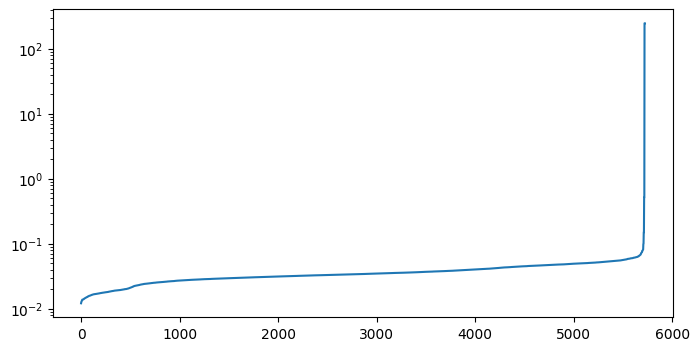

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))

plt.semilogy(np.sort(scores))

In [ ]:
print("Normal Median :", np.median(normal_scores))
print("Anomaly Median:", np.median(anomaly_scores))
for p in [50, 75, 90, 95, 99]:
    print(
        p,
        np.percentile(normal_scores, p),
        np.percentile(anomaly_scores, p)
    )

Normal Median : 0.039444335
Anomaly Median: 0.029891863
50 0.03944433480501175 0.02989186253398657
75 0.048178963363170624 0.03388070408254862
90 0.05384135022759438 0.03793855868279934
95 0.058268560841679556 0.041633255407214166
99 0.06804709941148758 0.04847098018974065


In [ ]:
print("Original :", roc_auc_score(labels, scores))

print("Flipped Labels :", roc_auc_score(1 - labels, scores))

Original : 0.17577051949490474
Flipped Labels : 0.8242294805050951


In [ ]:
collision = road.sets["collision"][0]

actions = collision[:, 0]
labels = collision[:, -1]

print("Unique Actions:", np.unique(actions))

Unique Actions: [0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333 0.66666667 0.7        0.73333333 0.76666667
 0.8        0.83333333 0.86666667 0.9        0.93333333 0.96666667
 1.        ]


In [ ]:
from collections import defaultdict

stats = defaultdict(lambda: {"normal": 0, "anomaly": 0})

for action, label in zip(actions, labels):

    if label == 0:
        stats[action]["normal"] += 1
    else:
        stats[action]["anomaly"] += 1

for action in sorted(stats):

    print(
        f"Action {action:.3f} | "
        f"Normal = {stats[action]['normal']:5d} | "
        f"Anomaly = {stats[action]['anomaly']:5d}"
    )

Action 0.100 | Normal =   280 | Anomaly =   248
Action 0.133 | Normal =   180 | Anomaly =   181
Action 0.233 | Normal =   492 | Anomaly =     8
Action 0.267 | Normal =   312 | Anomaly =     0
Action 0.367 | Normal =   151 | Anomaly =   389
Action 0.400 | Normal =    98 | Anomaly =   262
Action 0.567 | Normal =   230 | Anomaly =   100
Action 0.600 | Normal =   174 | Anomaly =   156
Action 0.633 | Normal =   266 | Anomaly =    34
Action 0.667 | Normal =   301 | Anomaly =     0
Action 0.700 | Normal =   300 | Anomaly =     0
Action 0.733 | Normal =   300 | Anomaly =     0
Action 0.767 | Normal =   161 | Anomaly =   169
Action 0.800 | Normal =   110 | Anomaly =   220
Action 0.833 | Normal =     0 | Anomaly =   300
Action 0.867 | Normal =     0 | Anomaly =   301


In [ ]:
scores, labels, actions = trainer.predict(test_loaders["all"])

for action in np.unique(actions):

    idx = actions == action

    print(
        f"{action:.3f}",
        scores[idx].mean(),
        scores[idx].std(),
        len(scores[idx])
    )

0.000 0.035416126 0.0048021725 35
0.033 0.04093654 0.01467692 145
0.067 0.03605173 0.012158365 138
0.100 0.03971813 0.03290929 478
0.133 0.04126424 0.03819657 339
0.167 0.038265865 0.012064771 129
0.200 0.034718346 0.010379356 127
0.233 0.037240572 0.010133713 479
0.267 0.036428723 0.010422356 303
0.300 0.03691462 0.022315014 136
0.333 0.031900484 0.009524355 167
0.367 1.0489241 15.817244 488
0.400 1.5217069 19.129486 333
0.433 0.03365487 0.008459023 157
0.467 0.031261135 0.008553822 155
0.500 0.036263984 0.010748389 138
0.533 0.032990135 0.010749152 143
0.567 0.03484184 0.012209068 154
0.600 0.032609824 0.010021704 177
0.633 0.03611141 0.011060478 147
0.667 0.034556624 0.010959735 155
0.700 0.03971684 0.01143874 129
0.733 0.0378622 0.01127215 127
0.767 0.03593767 0.009983035 145
0.800 0.03418694 0.009321305 135
0.833 0.037449412 0.01083771 112
0.867 0.03698102 0.0103793265 120
0.900 0.039817024 0.009432647 111
0.933 0.03887004 0.009487385 108
0.967 0.039346363 0.01135928 102
1.000 0.0

In [ ]:
unique_actions = np.unique(actions)

for action in unique_actions:

    idx = np.isclose(actions, action)

    s = scores[idx]

    if len(s) == 0:
        continue

    print(f"\nAction {action:.3f}")
    print("Count  :", len(s))
    print("Median :", np.median(s))
    print("95%    :", np.percentile(s, 95))
    print("99%    :", np.percentile(s, 99))
    print("Max    :", s.max())


Action 0.000
Count  : 35
Median : 0.034915313
95%    : 0.04690369516611099
99%    : 0.04719748146831989
Max    : 0.047231972

Action 0.033
Count  : 145
Median : 0.03714587
95%    : 0.06677137911319728
99%    : 0.10000753194093705
Max    : 0.10108532

Action 0.067
Count  : 138
Median : 0.033870935
95%    : 0.05492352731525898
99%    : 0.0733864963054657
Max    : 0.09965152

Action 0.100
Count  : 478
Median : 0.035792142
95%    : 0.05781215876340864
99%    : 0.0776668616384268
Max    : 0.5172701

Action 0.133
Count  : 339
Median : 0.036308914
95%    : 0.05861424989998336
99%    : 0.07623058810830118
Max    : 0.5173054

Action 0.167
Count  : 129
Median : 0.03695826
95%    : 0.05943914279341697
99%    : 0.06988117545843124
Max    : 0.07389379

Action 0.200
Count  : 127
Median : 0.034163408
95%    : 0.05295580103993414
99%    : 0.05554900810122489
Max    : 0.06031048

Action 0.233
Count  : 479
Median : 0.036050674
95%    : 0.05324322208762168
99%    : 0.06019532106816768
Max    : 0.0641712

In [ ]:
top_idx = np.argsort(scores)[-20:]

for i in top_idx:
    print(
        f"Index: {i}",
        f"Score: {scores[i]:.3f}",
        f"Label: {labels[i]}",
        f"Action: {actions[i]:.3f}"
    )

Index: 1142 Score: 0.081 Label: 0 Action: 0.567
Index: 1140 Score: 0.081 Label: 0 Action: 0.567
Index: 1141 Score: 0.081 Label: 0 Action: 0.567
Index: 2782 Score: 0.082 Label: 0 Action: 0.100
Index: 249 Score: 0.100 Label: 0 Action: 0.033
Index: 248 Score: 0.100 Label: 0 Action: 0.067
Index: 251 Score: 0.100 Label: 0 Action: 0.033
Index: 250 Score: 0.101 Label: 0 Action: 0.033
Index: 4371 Score: 0.151 Label: 1 Action: 0.300
Index: 4372 Score: 0.151 Label: 1 Action: 0.300
Index: 4374 Score: 0.151 Label: 1 Action: 0.300
Index: 4373 Score: 0.154 Label: 1 Action: 0.300
Index: 504 Score: 0.517 Label: 1 Action: 0.133
Index: 503 Score: 0.517 Label: 1 Action: 0.100
Index: 502 Score: 0.517 Label: 1 Action: 0.100
Index: 505 Score: 0.517 Label: 1 Action: 0.133
Index: 1045 Score: 247.615 Label: 0 Action: 0.367
Index: 1043 Score: 247.615 Label: 1 Action: 0.400
Index: 1044 Score: 247.616 Label: 1 Action: 0.367
Index: 1042 Score: 247.618 Label: 1 Action: 0.400


In [ ]:
for action in np.unique(actions):

    idx = np.isclose(actions, action)

    normal = scores[idx & (labels == 0)]
    anomaly = scores[idx & (labels == 1)]

    print(f"\nAction {action:.3f}")

    if len(normal):
        print("Normal Median :", np.median(normal))

    if len(anomaly):
        print("Anomaly Median:", np.median(anomaly))


Action 0.000
Normal Median : 0.035034053
Anomaly Median: 0.032798752

Action 0.033
Normal Median : 0.04256875
Anomaly Median: 0.030733557

Action 0.067
Normal Median : 0.038044605
Anomaly Median: 0.029981729

Action 0.100
Normal Median : 0.038979072
Anomaly Median: 0.031703547

Action 0.133
Normal Median : 0.038860653
Anomaly Median: 0.033784904

Action 0.167
Normal Median : 0.03857174
Anomaly Median: 0.03222544

Action 0.200
Normal Median : 0.035284195
Anomaly Median: 0.030444982

Action 0.233
Normal Median : 0.04139267
Anomaly Median: 0.03218974

Action 0.267
Normal Median : 0.04101964
Anomaly Median: 0.030015724

Action 0.300
Normal Median : 0.03838074
Anomaly Median: 0.02849966

Action 0.333
Normal Median : 0.036854997
Anomaly Median: 0.026017508

Action 0.367
Normal Median : 0.039447337
Anomaly Median: 0.028815102

Action 0.400
Normal Median : 0.040262345
Anomaly Median: 0.028825317

Action 0.433
Normal Median : 0.03845647
Anomaly Median: 0.028174406

Action 0.467
Normal Median :

In [ ]:
from sklearn.metrics import roc_auc_score

feature_aurocs = []

for f in range(85):

    feature_error = []

    all_labels = []

    model.eval()

    with torch.no_grad():

        for x, y, _ in test_loaders["all"]:

            x = x.to(device)

            recon = model(x)

            error = (x - recon).pow(2)

            # average over time only
            feature_error.extend(
                error.mean(dim=1)[:, f].cpu().numpy()
            )

            all_labels.extend(y.numpy())

    auc = roc_auc_score(all_labels, feature_error)

    feature_aurocs.append(auc)

order = np.argsort(feature_aurocs)

for i in order[::-1][:20]:
    print(i, feature_aurocs[i])

KeyboardInterrupt: 

In [ ]:
scores, labels = trainer.predict(test_loaders["all"])

In [ ]:
from sklearn.metrics import roc_auc_score

print("Normal AUROC :", roc_auc_score(labels, scores))

print("Negated AUROC:", roc_auc_score(labels, -scores))

Normal AUROC : 0.20142076922302332
Negated AUROC: 0.7985792307769768


In [ ]:
training = road.sets["training"]

print(len(training))

for i, rec in enumerate(training):

    print(i, rec.shape)

    print(np.unique(rec[:, -1], return_counts=True))

9
0 (37400, 86)
(array([0.]), array([37400], dtype=int64))
1 (21575, 86)
(array([0.]), array([21575], dtype=int64))
2 (74321, 86)
(array([0.]), array([74321], dtype=int64))
3 (5229, 86)
(array([0.]), array([5229], dtype=int64))
4 (18573, 86)
(array([0.]), array([18573], dtype=int64))
5 (19516, 86)
(array([0.]), array([19516], dtype=int64))
6 (18668, 86)
(array([0.]), array([18668], dtype=int64))
7 (33383, 86)
(array([0.]), array([33383], dtype=int64))
8 (5127, 86)
(array([0.]), array([5127], dtype=int64))


In [ ]:
print(training[0].shape)

(37400, 86)


In [ ]:
print(road.sets["collision"][0].shape)

print(road.sets["control"][0].shape)

print(road.sets["velocity"][0].shape)

print(road.sets["weight"][0].shape)

print(road.sets["training"][0].shape)

(15538, 87)
(74499, 87)
(22859, 87)
(18609, 87)
(37400, 86)


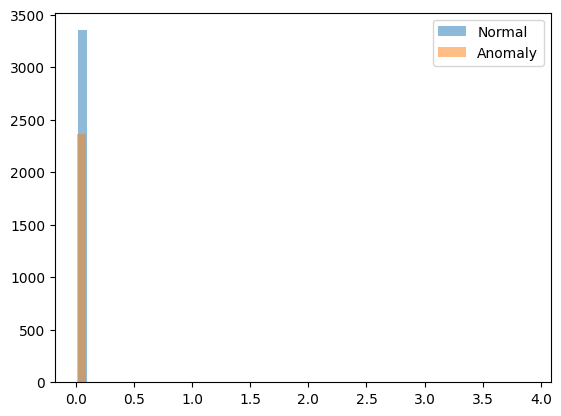

In [ ]:
scores, labels = trainer.predict(test_loaders["all"])

normal = scores[labels == 0]
anomaly = scores[labels == 1]

import matplotlib.pyplot as plt

plt.hist(normal, bins=50, alpha=0.5, label="Normal")
plt.hist(anomaly, bins=50, alpha=0.5, label="Anomaly")
plt.legend()
plt.show()

In [ ]:
scores, labels = trainer.predict(test_loaders["all"])

normal = scores[labels == 0]
anomaly = scores[labels == 1]

print(normal.mean(), anomaly.mean())

print(
    roc_auc_score(labels, scores),
    roc_auc_score(labels, -scores)
)

0.033666886 0.027862877
0.20142076922302332 0.7985792307769768


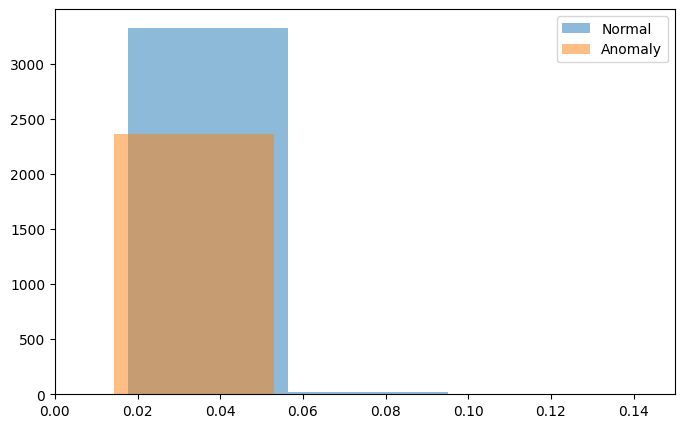

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(normal, bins=100, alpha=0.5, label="Normal")
plt.hist(anomaly, bins=100, alpha=0.5, label="Anomaly")

plt.xlim(0, 0.15)

plt.legend()
plt.show()

In [ ]:
collision = road.sets["collision"][0]

labels = collision[:, -1]

print(np.unique(labels))

[0. 1.]


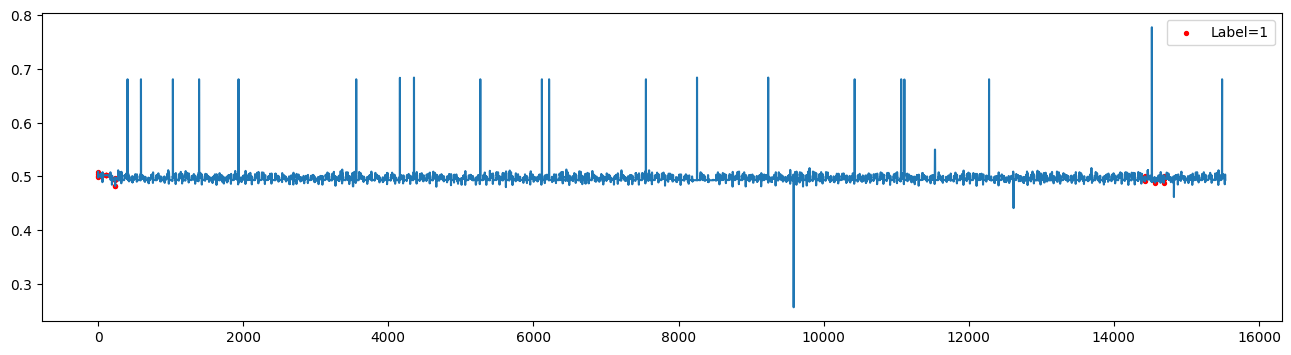

In [ ]:
import matplotlib.pyplot as plt

feature = collision[:, 10]

plt.figure(figsize=(16,4))

plt.plot(feature)

idx = np.where(labels == 1)[0]

plt.scatter(
    idx,
    feature[idx],
    color="red",
    s=8,
    label="Label=1"
)

plt.legend()
plt.show()

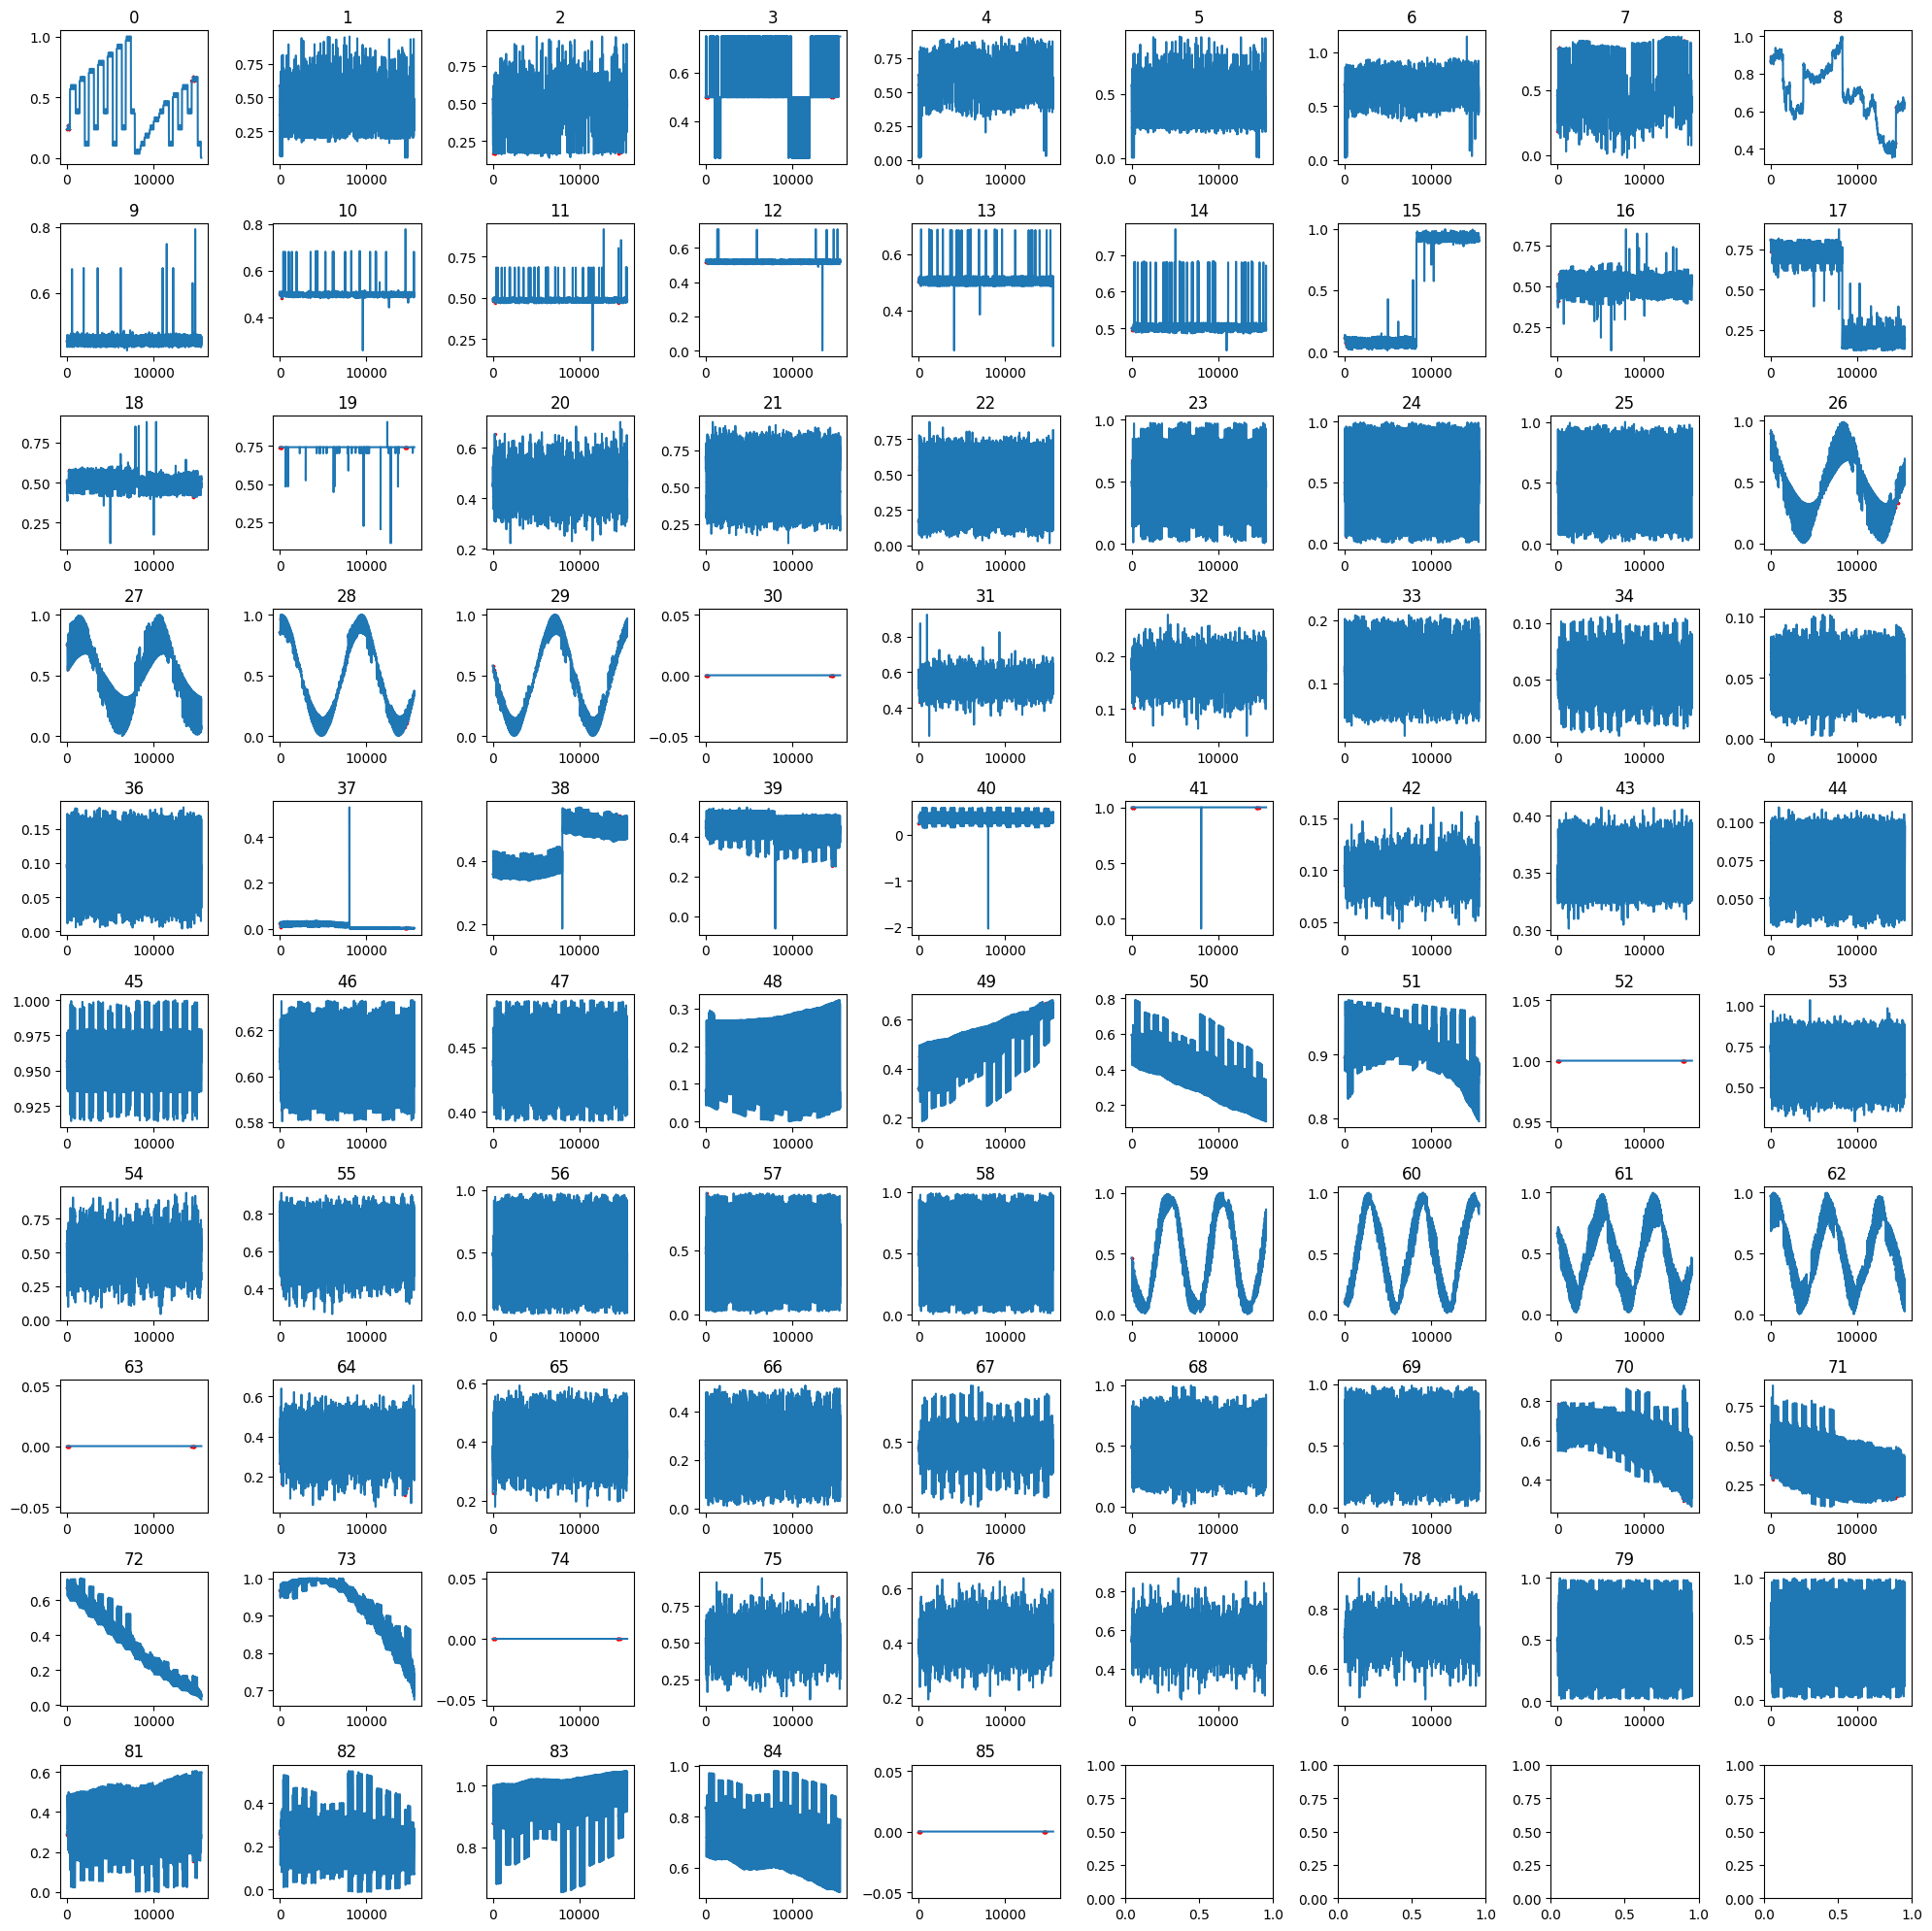

In [ ]:
fig, axes = plt.subplots(
    10,
    9,
    figsize=(20,20)
)

axes = axes.flatten()

for i in range(86):

    axes[i].plot(collision[:, i])

    idx = np.where(labels == 1)[0]

    axes[i].scatter(
        idx,
        collision[idx, i],
        s=2,
        c="red"
    )

    axes[i].set_title(str(i))

plt.tight_layout()

In [ ]:
feature_scores = []
for f in range(error.shape[1]):

    auc = roc_auc_score(
        labels,
        error[:, f]
    )

    feature_scores.append((f, auc))

feature_scores.sort(
    key=lambda x: x[1],
    reverse=True
)

print(feature_scores[:10])